In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

### Data Generation

In [4]:
from src.sim_data import *

df_train, df_val, coeffs_dict = generate_data_with_Z(Aucs_train=1000, Ads_train=50,
                                        num_X=25,
                                        random_impressions=2000000)

df_train.to_pickle('sim/data/df_train.pkl')
df_val.to_pickle('sim/data/df_val.pkl')
np.savez('sim/data/coeffs_dict.pkl', **coeffs_dict)

## Please comment out if you load simulation data again.
#df_train = pd.read_pickle('sim/data/df_train.pkl')
#df_val = pd.read_pickle('sim/data/df_val.pkl')
#coeffs_dict= np.load('sim/data/coeffs_dict.pkl', allow_pickle=True)
#coeffs_dict = {key: coeffs_dict[key].item() for key in coeffs_dict.keys()}

/Users/emo_157/Desktop/24_coldstart/KDD24_IV_pCTR/src/sim_data.py:58: RuntimeWarning: overflow encountered in exp
  sigmoid_prob_for_intervention = 1 / (1 + np.exp(-linear_prob_for_intervention))


In [15]:
from src.models_utils import *

X_train, z_train, y_train_imp, y_train_clk = convert_to_keras_input(df_train)

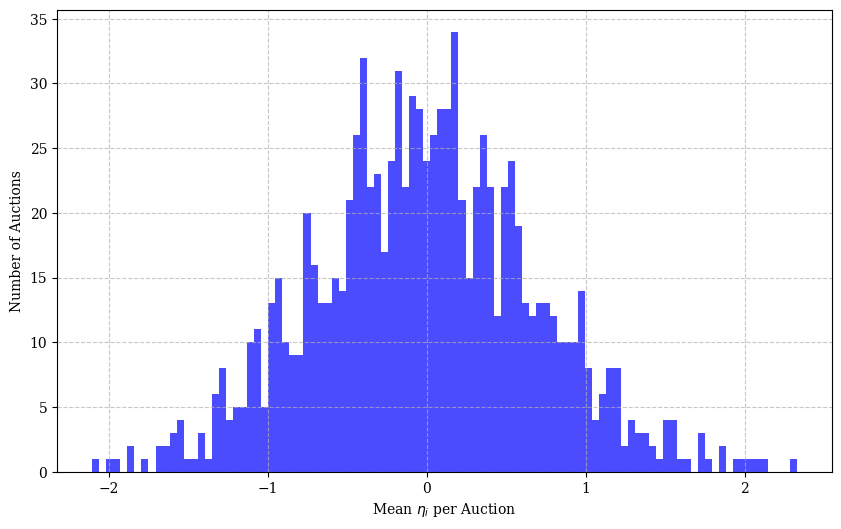

In [17]:
## Plotting mean eta by auction
mean_eta_per_auction = df_train.groupby('auction_id')['eta'].mean()

plt.rc('text', usetex=False)
plt.rc('font', family='serif')

plt.figure(figsize=(10, 6))
plt.hist(mean_eta_per_auction, bins=100, color='blue', alpha=0.7)
plt.xlabel('Mean $\eta_i$ per Auction')
plt.ylabel('Number of Auctions')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig(f"sim/figs/mean_eta_hist.pdf", dpi=300, format='pdf', bbox_inches='tight')
plt.show()

In [19]:
## Plotting How Skewed the function Form Without Omitted Variables

df = df_train.copy()
df_intervention = df[df['intervention'] == 1]

# Splitting features and outcome
X_with_eta = df_intervention[[f'x_{i}' for i in range(25)] + ['eta']]
y = df_intervention['outcome']

X_without_eta = df_intervention[[f'x_{i}' for i in range(25)]]

# Initializing Models
model_with_eta = LogisticRegression()
model_without_eta = LogisticRegression()

model_with_eta.fit(X_with_eta, y)
model_without_eta.fit(X_without_eta, y)

probs_with_eta = model_with_eta.predict_proba(X_with_eta)[:, 1]
probs_without_eta = model_without_eta.predict_proba(X_without_eta)[:, 1]

# True Function Form
coefficients_X_outcome = coeffs_dict['coefficients_X_outcome']
intercept_outcome = coeffs_dict['intercept_outcome']

linear_prob = (
    intercept_outcome +
    np.sum(X_without_eta * coefficients_X_outcome, axis=1) +
    df_intervention["eta"]
)

sigmoid_prob = 1 / (1 + np.exp(-linear_prob))
outcome = np.random.binomial(1, sigmoid_prob)

# True CDF
values, base = np.histogram(sigmoid_prob, bins=500, density=False)
cumulative = np.cumsum(values) / values.sum()

# Predicted CDF with eta
values_with_eta, base_with_eta = np.histogram(probs_with_eta, bins=500, density=False)
cumulative_with_eta = np.cumsum(values_with_eta) / values_with_eta.sum()

# Predicted CDF without eta
values_without_eta, base_without_eta = np.histogram(probs_without_eta, bins=500, density=False)
cumulative_without_eta = np.cumsum(values_without_eta) / values_without_eta.sum()

# Plotting the CDF
plt.rc('text', usetex=False)
plt.rc('font', family='serif')
plt.figure(figsize=(10, 6))
plt.plot(base[:-1], cumulative, c='blue', label='True CDF')
plt.plot(base_with_eta[:-1], cumulative_with_eta, c='green', label='With $\eta_i$ CDF')
plt.plot(base_without_eta[:-1], cumulative_without_eta, c='red', label='Without $\eta_i$ CDF')
plt.legend()
plt.xlabel('Probabilities')
plt.ylabel('Cumulative Distribution Function')
#plt.title('Comparison of CDFs')
plt.grid(True)
plt.legend()
plt.savefig(f"sim/figs/skewed_function.pdf", dpi=300, format='pdf', bbox_inches='tight')
plt.show()

NameError: name 'coeffs_dict' is not defined

### Comparing Approaches

In [ ]:
### Naive approach
inputs = {key: tf.keras.layers.Input(shape=(1,), name=key) for key in X_train.keys()}

input_num = tf.keras.layers.Concatenate(axis=-1)(list(inputs.values()))
input_num = tf.keras.layers.BatchNormalization()(input_num)

pCTR = tf.keras.layers.Dense(256, activation="swish")(input_num)
pCTR = tf.keras.layers.BatchNormalization()(pCTR)
pCTR = tf.keras.layers.Dense(256, activation="relu")(pCTR)
pCTR = tf.keras.layers.BatchNormalization()(pCTR)
pCTR = tf.keras.layers.Dense(256, activation="relu")(pCTR)
pCTR = tf.keras.layers.BatchNormalization()(pCTR)
pCTR = tf.keras.layers.Dense(1, activation="sigmoid", name="click")(pCTR)
pCTR = tf.keras.Model(inputs=list(inputs.values()), outputs=pCTR)

model = tf.keras.Model(
    inputs=list(inputs.values()), outputs=pCTR.output
)
model.compile(
    optimizer=tf.keras.optimizers.Adamax(learning_rate=0.001),
    loss="binary_crossentropy",
)

cp_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath="sim/checkpoints/naive_checkpoint",
    save_best_only=True,
    verbose=1,
    monitor="loss",
)

model.fit(X_train, y_train_clk, sample_weight=y_train_imp, epochs=10, steps_per_epoch=1000, callbacks=[cp_callback])

In [ ]:
### baseline IV approach
import tensorflow as tf

inputs = {key: tf.keras.layers.Input(shape=(1,), name=key) for key in X_train.keys()}
inputs_iv = {"z": tf.keras.layers.Input(shape=(1,), name="z")}
inputs_with_iv = {**inputs, **inputs_iv}

inputs_net = tf.keras.layers.Concatenate(axis=-1)(list(inputs.values()))
inputs_iv_net = list(inputs_iv.values())[0]
inputs_net_iv = tf.keras.layers.Concatenate(axis=-1)([inputs_net, inputs_iv_net])

pIMP_iv = tf.keras.layers.Dense(128, activation="swish")(inputs_net_iv)
pIMP_iv = tf.keras.layers.BatchNormalization()(pIMP_iv)
pIMP_iv = tf.keras.layers.Dense(1, activation="sigmoid", name="impression_iv")(pIMP_iv)
pIMP_iv = tf.keras.Model(inputs=inputs_with_iv, outputs=pIMP_iv)

input_net = tf.keras.layers.Concatenate(axis=-1)([inputs_net, pIMP_iv.output])
pCTR = tf.keras.layers.Dense(256, activation="swish")(input_net)
pCTR = tf.keras.layers.BatchNormalization()(pCTR)
pCTR = tf.keras.layers.Dense(256, activation="relu")(pCTR)
pCTR = tf.keras.layers.BatchNormalization()(pCTR)
pCTR = tf.keras.layers.Dense(256, activation="relu")(pCTR)
pCTR = tf.keras.layers.BatchNormalization()(pCTR)
pCTR = tf.keras.layers.Dense(1, activation="sigmoid", name="click")(pCTR)
pCTR = tf.keras.Model(inputs=inputs_with_iv, outputs=pCTR)

model = tf.keras.Model(
    inputs=inputs_with_iv, outputs=[pCTR.output, pIMP_iv.output]
)
model.compile(
    optimizer=tf.keras.optimizers.Adamax(learning_rate=0.001),
    loss="binary_crossentropy",
)

cp_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath="sim/checkpoints/baselineIV_checkpoint/checkpoint",
    save_best_only=True,
    verbose=1,
    monitor="click_loss",
)

imp_weight = np.ones_like(y_train_imp)
model.fit({**X_train, **z_train}, [y_train_clk, y_train_imp], sample_weight=[y_train_imp,imp_weight], epochs=50, steps_per_epoch=1000, callbacks=[cp_callback])

In [12]:
### IPS
## pIMP
inputs = {key: tf.keras.layers.Input(shape=(1,), name=key) for key in X_train.keys()}
inputs_iv = {"z": tf.keras.layers.Input(shape=(1,), name="z")}
inputs_with_iv = {**inputs, **inputs_iv} 

inputs_net = tf.keras.layers.Concatenate(axis=-1)(list(inputs.values()))
inputs_iv_net = list(inputs_iv.values())[0]
inputs_net_iv = tf.keras.layers.Concatenate(axis=-1)([inputs_net, inputs_iv_net])

pIMP_iv = tf.keras.layers.Dense(128, activation="swish")(inputs_net_iv)
pIMP_iv = tf.keras.layers.BatchNormalization()(pIMP_iv)
pIMP_iv = tf.keras.layers.Dense(1, activation="sigmoid", name="impression_iv")(pIMP_iv)
pIMP_iv = tf.keras.Model(inputs=inputs_with_iv, outputs=pIMP_iv)

model = tf.keras.Model(
    inputs=inputs_with_iv, outputs=pIMP_iv.output)

model.compile(
    optimizer=tf.keras.optimizers.Adamax(learning_rate=0.001),
    loss="binary_crossentropy",
)

cp_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath="sim/checkpoints/ips/ipsimp_checkpoint",
    save_best_only=True,
    verbose=1,
    monitor="loss",
)

model.fit({**X_train, **z_train}, y_train_imp, epochs=50, steps_per_epoch=1000, callbacks=[cp_callback])

## pCTR
inputs = {key: tf.keras.layers.Input(shape=(1,), name=key) for key in X_train.keys()} 
inputs_net = tf.keras.layers.Concatenate(axis=-1)(list(inputs.values()))

pCTR = tf.keras.layers.Dense(256, activation="swish")(inputs_net)
pCTR = tf.keras.layers.BatchNormalization()(pCTR)
pCTR = tf.keras.layers.Dense(256, activation="relu")(pCTR)
pCTR = tf.keras.layers.BatchNormalization()(pCTR)
pCTR = tf.keras.layers.Dense(256, activation="relu")(pCTR)
pCTR = tf.keras.layers.BatchNormalization()(pCTR)
pCTR = tf.keras.layers.Dense(1, activation="sigmoid", name="click")(pCTR)
pCTR = tf.keras.Model(inputs=inputs, outputs=pCTR)

model = tf.keras.Model(
    inputs=inputs, outputs=pCTR.output)

model.compile(
    optimizer=tf.keras.optimizers.Adamax(learning_rate=0.001),
    loss="binary_crossentropy"
)

cp_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath="sim/checkpoints/ips/ipsclk_checkpoint",
    save_best_only=True,
    verbose=1,
    monitor="loss",
)

ipsimp = tf.keras.models.load_model("sim/checkpoints/ips/ipsimp_checkpoint")
ips_weight = ipsimp.predict({**X_train, **z_train}, batch_size=200000, verbose=1)
weight_mask = [y_train_imp==1]
model.fit({**X_train, **z_train}, y_train_clk, sample_weight = ips_weight, epochs=50, steps_per_epoch=1000, callbacks=[cp_callback])

 984/1000 [============================>.] - ETA: 0s - loss: 0.0025
Epoch 6: loss improved from 0.00262 to 0.00247, saving model to sim/checkpoints/ips/ipsclk_checkpoint
INFO:tensorflow:Assets written to: sim/checkpoints/ips/ipsclk_checkpoint/assets


INFO:tensorflow:Assets written to: sim/checkpoints/ips/ipsclk_checkpoint/assets


1000/1000 [==============================] - 4s 4ms/step - loss: 0.0025
Epoch 7/50
 989/1000 [============================>.] - ETA: 0s - loss: 0.0024
Epoch 7: loss improved from 0.00247 to 0.00240, saving model to sim/checkpoints/ips/ipsclk_checkpoint
INFO:tensorflow:Assets written to: sim/checkpoints/ips/ipsclk_checkpoint/assets


INFO:tensorflow:Assets written to: sim/checkpoints/ips/ipsclk_checkpoint/assets


1000/1000 [==============================] - 3s 3ms/step - loss: 0.0024
Epoch 8/50
 979/1000 [============================>.] - ETA: 0s - loss: 0.0023
Epoch 8: loss improved from 0.00240 to 0.00229, saving model to sim/checkpoints/ips/ipsclk_checkpoint
INFO:tensorflow:Assets written to: sim/checkpoints/ips/ipsclk_checkpoint/assets


...

1000/1000 [==============================] - 3s 3ms/step - loss: 3.2722e-04
Epoch 46/50
 996/1000 [============================>.] - ETA: 0s - loss: 3.3178e-04
Epoch 46: loss did not improve from 0.00033
1000/1000 [==============================] - 2s 2ms/step - loss: 3.3136e-04
Epoch 47/50
 997/1000 [============================>.] - ETA: 0s - loss: 2.9975e-04
Epoch 47: loss improved from 0.00033 to 0.00030, saving model to sim/checkpoints/ips/ipsclk_checkpoint
INFO:tensorflow:Assets written to: sim/checkpoints/ips/ipsclk_checkpoint/assets


INFO:tensorflow:Assets written to: sim/checkpoints/ips/ipsclk_checkpoint/assets


1000/1000 [==============================] - 3s 3ms/step - loss: 2.9940e-04
Epoch 48/50
 988/1000 [============================>.] - ETA: 0s - loss: 3.0336e-04
Epoch 48: loss did not improve from 0.00030
1000/1000 [==============================] - 2s 2ms/step - loss: 3.0423e-04
Epoch 49/50
 997/1000 [============================>.] - ETA: 0s - loss: 3.1032e-04
Epoch 49: loss did not improve from 0.00030
1000/1000 [==============================] - 4s 4ms/step - loss: 3.0999e-04
Epoch 50/50
 996/1000 [============================>.] - ETA: 0s - loss: 2.8037e-04
Epoch 50: loss improved from 0.00030 to 0.00028, saving model to sim/checkpoints/ips/ipsclk_checkpoint
INFO:tensorflow:Assets written to: sim/checkpoints/ips/ipsclk_checkpoint/assets


INFO:tensorflow:Assets written to: sim/checkpoints/ips/ipsclk_checkpoint/assets


1000/1000 [==============================] - 4s 4ms/step - loss: 2.7995e-04


### Evaluation

In [ ]:
## Loading the models
sim_naive = tf.keras.models.load_model("sim/checkpoints/naive_checkpoint")
sim_iv = tf.keras.models.load_model("sim/checkpoints/baselineIV_checkpoint")
sim_ipsctr = tf.keras.models.load_model("sim/checkpoints/ips/ipsclk_checkpoint")

In [3]:
## Evaluation by Outside Quantiles
eta_per_auction_val = df_val['eta']

filtered_dfs = {}  

for lower_quantile in range(5, 51, 5):
    upper_quantile = 100 - lower_quantile

    lower_bound = eta_per_auction_val.quantile(lower_quantile / 100)
    upper_bound = eta_per_auction_val.quantile(upper_quantile / 100)

    relevant_auction_ids = eta_per_auction_val[
        (eta_per_auction_val <= lower_bound) | (eta_per_auction_val >= upper_bound)
    ].index

    filtered_df = df_val[df_val.index.isin(relevant_auction_ids)]
    filtered_dfs[f"{lower_quantile*2}"] = filtered_df


for key, value in filtered_dfs.items():
    print(f"For Outside Quantiles {key}%, number of rows: {len(value)}")

For quantiles 10%, number of rows: 200000
For quantiles 20%, number of rows: 400000
For quantiles 30%, number of rows: 600000
For quantiles 40%, number of rows: 800000
For quantiles 50%, number of rows: 1000000
For quantiles 60%, number of rows: 1200000
For quantiles 70%, number of rows: 1400000
For quantiles 80%, number of rows: 1600000
For quantiles 90%, number of rows: 1800000
For quantiles 100%, number of rows: 2000000


In [4]:
from sklearn.metrics import roc_auc_score

models_dict = {"naive":sim_naive , "baseline-iv":sim_iv, "ips": sim_ipsctr}
thresholds = list(filtered_dfs.keys())
results = {model_name: {"roc_aucs": np.zeros_like(thresholds, dtype=float),}
                        for model_name in models_dict.keys()}

for idx, threshold in enumerate(thresholds):

    features_val = {col: filtered_dfs[threshold][col].values for col in filtered_dfs[threshold].columns if col.startswith("x_")}
    features_val_Z = {col: filtered_dfs[threshold][col].values for col in filtered_dfs[threshold].columns if col.startswith("x_")or col=="z"}
    y_val = filtered_dfs[threshold]["outcome"]

    for model_name, model_instance in models_dict.items():
        if model_name in ["naive", "ips"]:
            p1 = model_instance.predict(features_val, batch_size=200000, verbose=1)
            results[model_name]["roc_aucs"][idx] = roc_auc_score(y_val, p1)       
        else :
            p1 = model_instance.predict(features_val_Z, batch_size=200000, verbose=1)
            results[model_name]["roc_aucs"][idx] = roc_auc_score(y_val, p1[0])

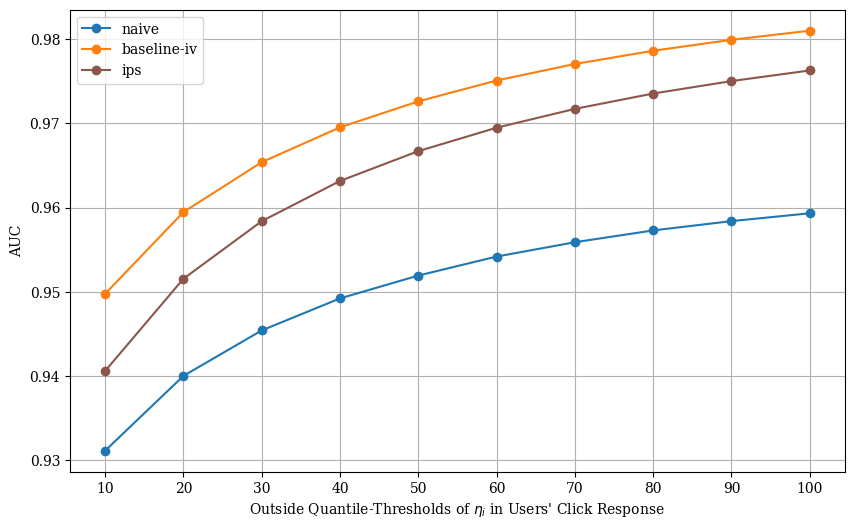

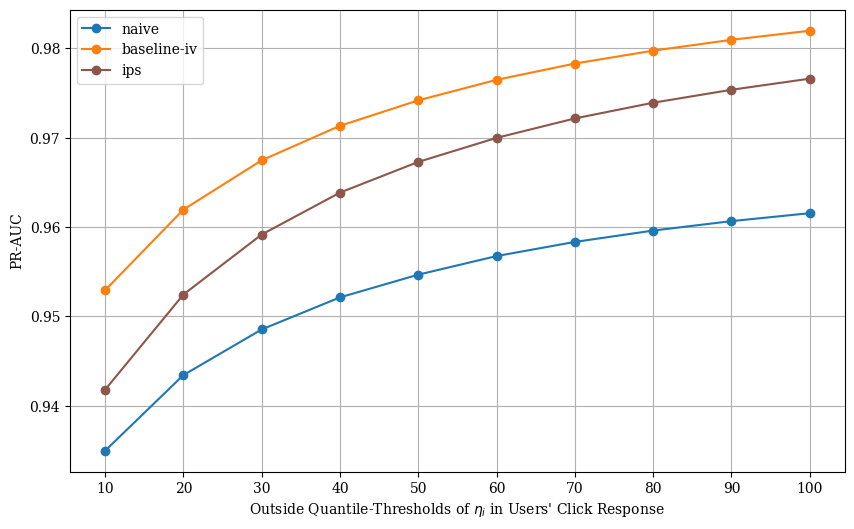

In [17]:
import matplotlib.pyplot as plt

plt.rc('text', usetex=False)
plt.rc('font', family='serif')

metrics = ["roc_aucs"]
model_order = ['naive', 'baseline-iv', 'ips']
colors = {
    'naive': '#1f77b4',    
    'baseline-iv': '#ff7f0e',
    'ips': '#8c564b',
}

ylabels = ["AUC"]
quantiles = list(filtered_dfs.keys())

for idx, (metric, ylabel) in enumerate(zip(metrics, ylabels)):
    plt.figure(figsize=(10, 6))
    for model_name in models_dict.keys():
        color = colors[model_name]
        if metric in ["roc_aucs"]:
            plt.plot(quantiles, ((loaded_results[model_name][metric]-0.5)/(loaded_results["naive"][metric]-0.5)-1),color=color, marker='o', label=model_name)
            #plt.plot(quantiles, loaded_results[model_name][metric], color=color, marker='o', label=model_name)
        else:
            plt.plot(quantiles, np.abs(loaded_results[model_name][metric] - 1) / np.abs(loaded_results["naive"][metric] - 1), color=color, marker='o', label=model_name)
            #plt.plot(quantiles, loaded_results[model_name][metric], marker='o', label=model_name)

    plt.xlabel("Outside Quantile-Thresholds of $\eta_i$ in Users' Click Response")
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.legend()

    plt.savefig(f"sim/figs/Quantiles_eval_{idx}.pdf", dpi=300, format='pdf', bbox_inches='tight')
    plt.show()